In [241]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    data = {}

    for table in tables:
        data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'year' загружена! (строк: 60)
Таблица 'доступность' загружена! (строк: 12)
Таблица 'bank_db' загружена! (строк: 36)
Таблица 'app' загружена! (строк: 12)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_7944\2392872286.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_7944\2392872286.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


In [242]:
df_finance = data['bank_db'] 
df_apps = data['app'][['id', 'rank']]

final = pd.merge(df_finance, df_apps, on='id', how='inner')
for_5=data['year']
filial = data['доступность']


In [243]:
print(final.columns.tolist())
print(for_5.columns.tolist())
print(filial.columns.tolist())

['id', 'bank', 'year', '%income', '%expence', 'net%income', 'com_income', 'com_outcome', 'net_com_income', 'FX income', 'op_expence', 'net_profit', 'loan', 'deposit', 'assets', 'capital', 'capital_adequacy', 'NPL', 'rank']
['Column1', 'bank', 'year', '%income', '%expence', 'net%income', 'com_income', 'com_outcome', 'net_com_income', 'FX income', 'op_expence ', 'net_profit', 'loan ', 'deposit', 'assets', 'capital ', ' (К 2,1)', 'NPL']
['id', 'bank', 'Банк', 'Филиалы / СК*', 'Терминалы / Банкоматы', 'Режим работы (стандарт)', 'График (будни)', 'Суббота', 'Итого часов в год (прибл.)']


In [244]:
final.drop(['id'], axis=1).describe()

,year,%income,%expence,net%income,com_income,com_outcome,net_com_income,FX income,op_expence,net_profit,loan,deposit,assets,capital,capital_adequacy,NPL,rank
count,36.000000,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,36.000000,3.600000e+01,36.000000
mean,2024.000000,4.632305e+06,1.804554e+06,2.827751e+06,1.546859e+06,1.182829e+06,3.640297e+05,2.263846e+06,3.368485e+06,2.334309e+06,2.601894e+07,4.802339e+07,6.680484e+07,1.092210e+07,23.151389,1.423793e+06,4.220833
std,0.828079,3.138402e+06,1.675767e+06,2.127233e+06,1.467958e+06,1.171705e+06,6.202875e+05,2.394702e+06,2.642250e+06,2.411608e+06,1.964638e+07,4.230604e+07,5.950555e+07,1.372905e+07,14.793775,1.350601e+06,0.430431
min,2023.000000,4.483290e+05,6.552900e+04,-6.770410e+05,1.514650e+05,6.552900e+04,-8.744430e+05,1.428290e+05,2.313370e+05,6.548800e+04,2.557343e+06,1.334432e+06,4.854278e+06,8.170080e+05,13.500000,1.631000e+04,3.500000
25%,2023.000000,1.787200e+06,7.534912e+05,8.901798e+05,4.342612e+05,3.792430e+05,6.453750e+04,5.183052e+05,1.241615e+06,2.650238e+05,9.881109e+06,1.076026e+07,1.772734e+07,4.189540e+06,16.100000,4.112812e+05,3.920000
50%,2024.000000,4.372873e+06,1.422766e+06,2.680073e+06,1.140821e+06,8.148760e+05,2.533030e+05,1.257244e+06,2.971335e+06,1.948064e+06,2.166113e+07,4.474103e+07,5.844009e+07,9.070410e+06,19.200000,8.571230e+05,4.185000
75%,2025.000000,6.204290e+06,2.167605e+06,3.998875e+06,2.068615e+06,1.415802e+06,5.796772e+05,3.605918e+06,4.436235e+06,3.060150e+06,3.636500e+07,6.259004e+07,8.725723e+07,1.213868e+07,24.500000,2.152860e+06,4.677500
max,2025.000000,1.369702e+07,8.328386e+06,7.613982e+06,7.158875e+06,4.354844e+06,2.804031e+06,7.958722e+06,1.158713e+07,8.322179e+06,8.367159e+07,1.610227e+08,2.656848e+08,8.114297e+07,94.500000,5.328545e+06,4.800000


In [245]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# очистка
final.columns = final.columns.str.strip()
final = final.fillna(0)

# 3 year mean 
avg = final.groupby('bank').mean(numeric_only=True).reset_index()

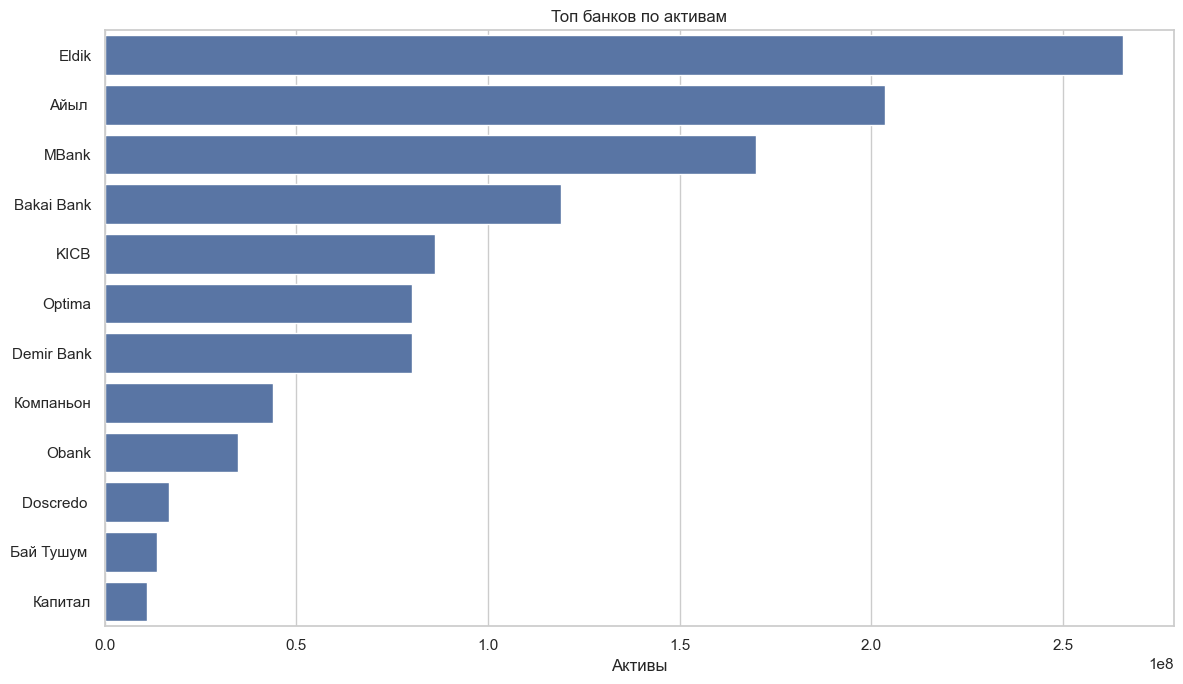

In [246]:
latest = for_5[for_5['year'] == for_5['year'].max()].copy()
latest = latest.sort_values('assets', ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(data=latest, y='bank', x='assets')

plt.title('Топ банков по активам')
plt.xlabel('Активы')
plt.ylabel('')

plt.tight_layout()
plt.show()

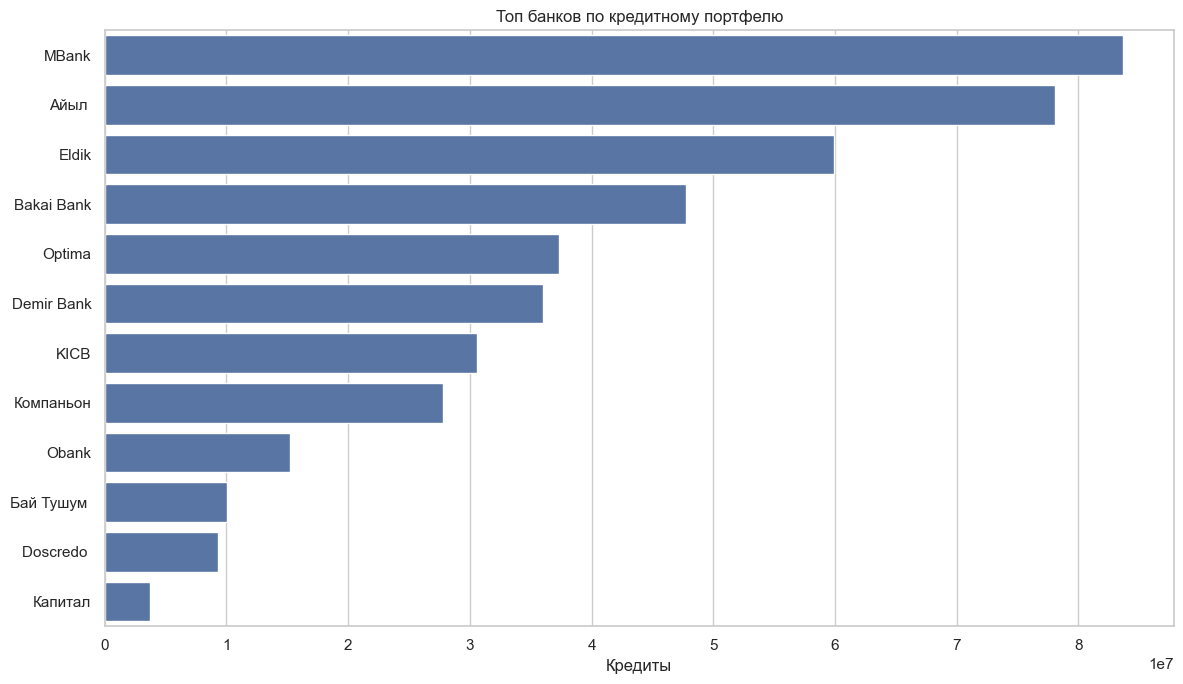

In [247]:
latest = for_5[for_5['year'] == for_5['year'].max()].copy()
latest = latest.sort_values('loan ', ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(data=latest, y='bank', x='loan ')

plt.title('Топ банков по кредитному портфелю')
plt.xlabel('Кредиты')
plt.ylabel('')

plt.tight_layout()
plt.show()

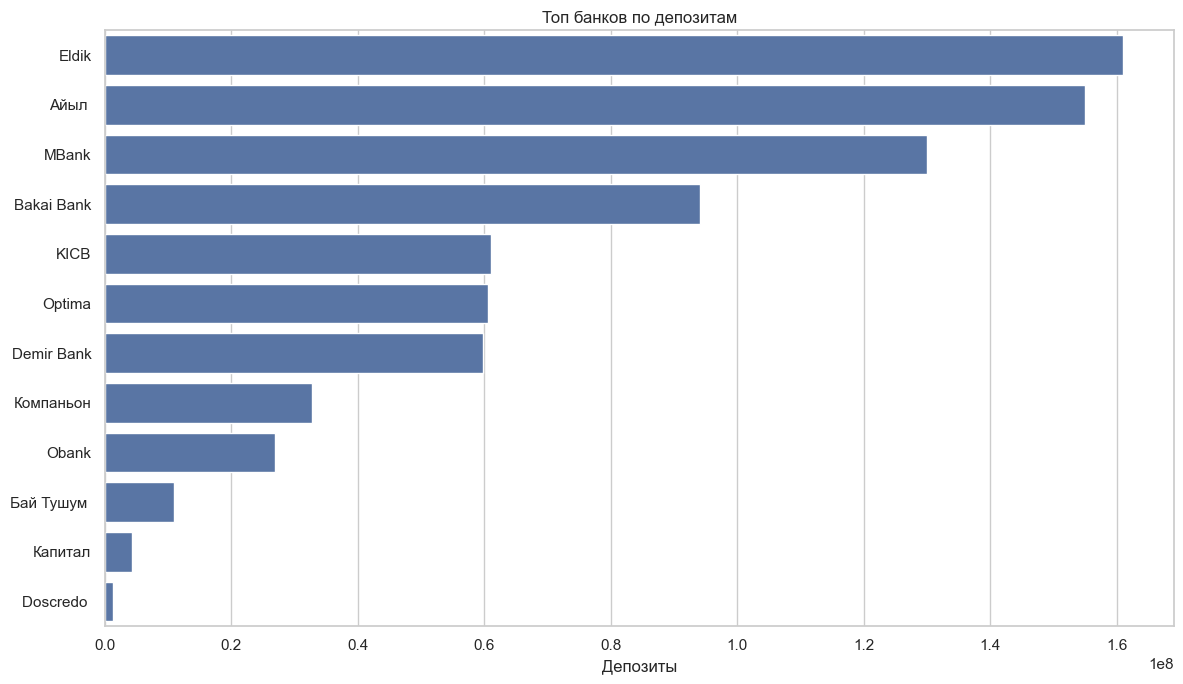

In [248]:
latest = latest.sort_values('deposit', ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(data=latest, y='bank', x='deposit')

plt.title('Топ банков по депозитам')
plt.xlabel('Депозиты')
plt.ylabel('')

plt.tight_layout()
plt.show()

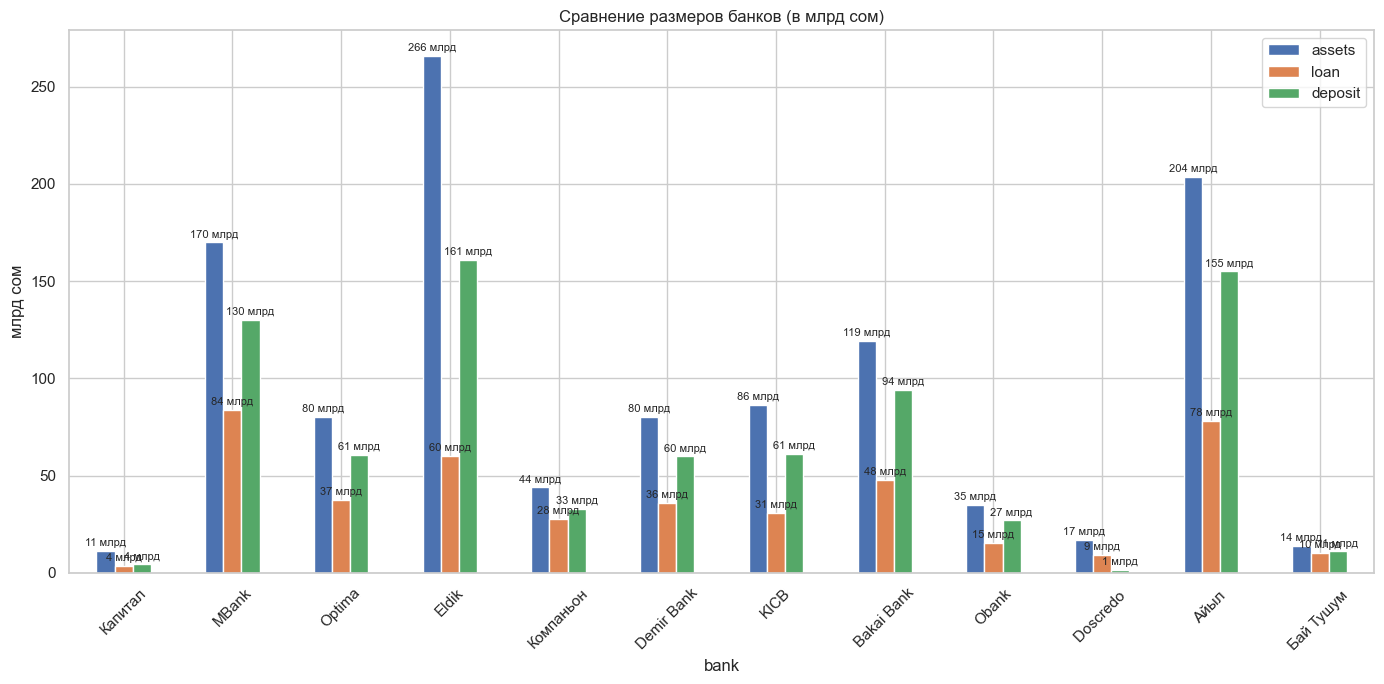

In [249]:
import matplotlib.pyplot as plt

# очистим названия колонок
for_5.columns = for_5.columns.str.strip()

latest = for_5[for_5['year'] == for_5['year'].max()].copy()

# переводим в млрд (если данные в тысячах)
market = latest[['bank','assets','loan','deposit']].set_index('bank') / 1_000_000

ax = market.plot(kind='bar', figsize=(14,7))

# функция форматирования
def format_billions(x):
    return f'{x:.0f} млрд' if x >= 1 else f'{x:.0f} млн'


# подписи
for container in ax.containers:
    labels = [format_billions(v) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.title('Сравнение размеров банков (в млрд сом)')
plt.ylabel('млрд сом')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='net_profit', ylabel='bank'>

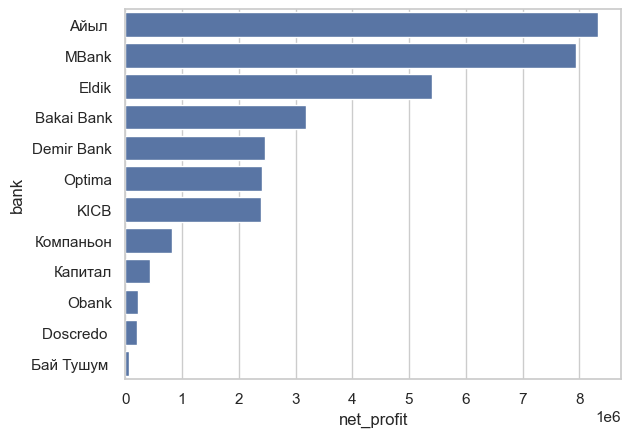

In [250]:
sns.barplot(data=latest.sort_values('net_profit', ascending=False),
            y='bank', x='net_profit')

<Axes: xlabel='roa', ylabel='bank'>

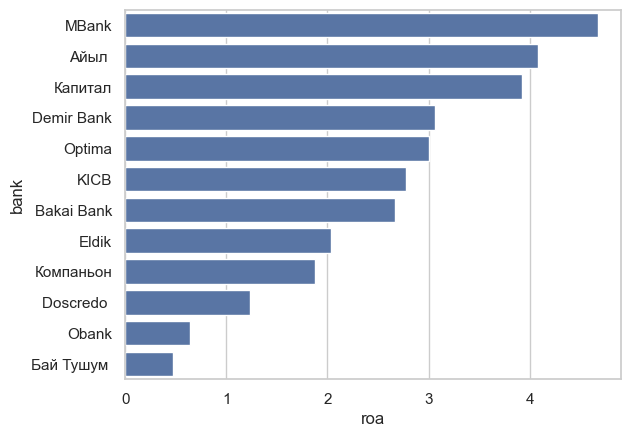

In [251]:
for_5['roa'] = for_5['net_profit'] / for_5['assets'] * 100
latest = for_5[for_5['year'] == for_5['year'].max()]
sns.barplot(data=latest.sort_values('roa', ascending=False),
            y='bank', x='roa')

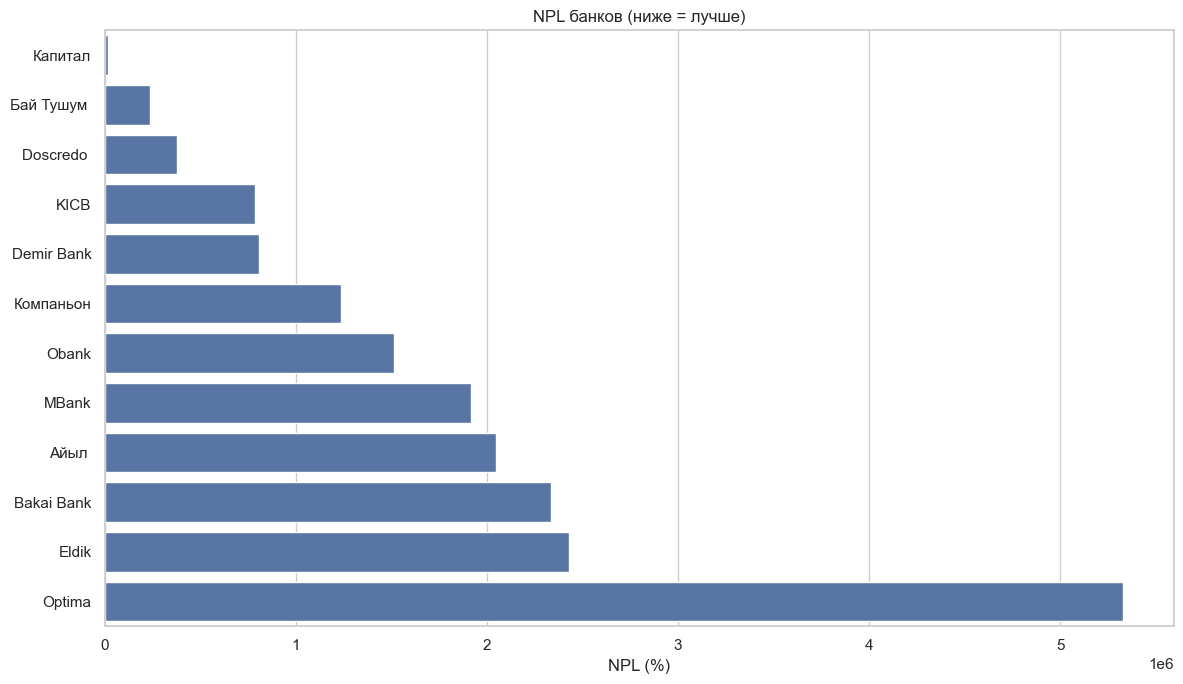

In [252]:
for_5.columns = for_5.columns.str.strip()
latest = for_5[for_5['year'] == for_5['year'].max()].copy()

plt.figure(figsize=(12,7))

sns.barplot(
    data=latest.sort_values('NPL', ascending=True),
    y='bank',
    x='NPL'
)

plt.title('NPL банков (ниже = лучше)')
plt.xlabel('NPL (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

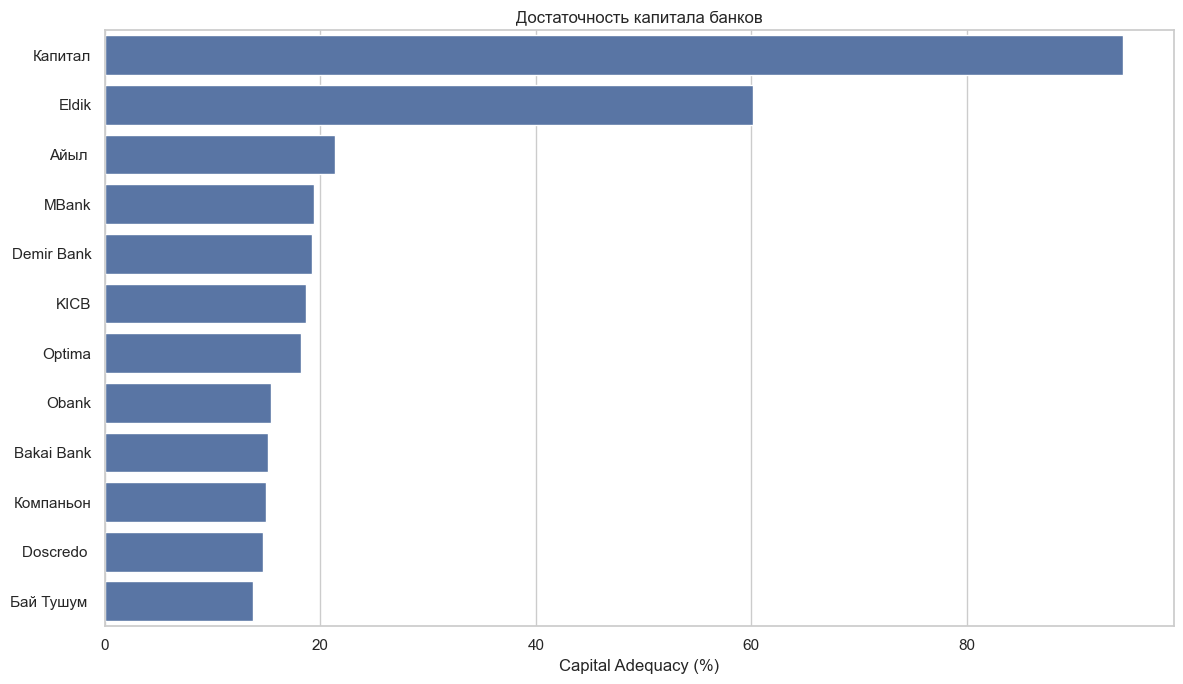

In [253]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=latest.sort_values('(К 2,1)', ascending=False),
    y='bank',
    x='(К 2,1)'
)

plt.title('Достаточность капитала банков')
plt.xlabel('Capital Adequacy (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()


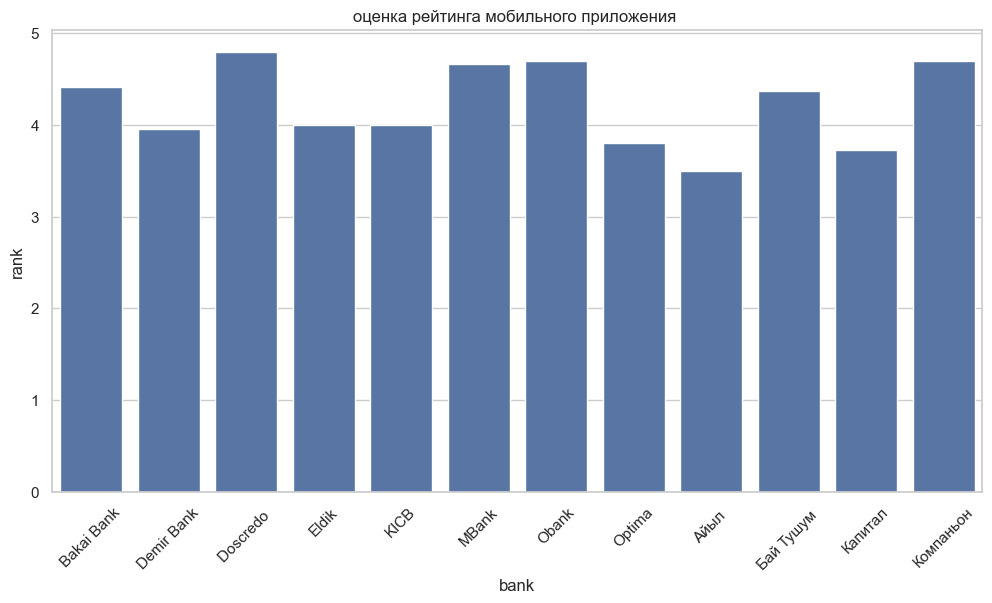

In [254]:
#Анализ цифровизации или приложения банка и их рейтинг
plt.figure(figsize=(12,6))
sns.barplot(data=avg, x='bank', y='rank')
plt.xticks(rotation=45)
plt.title("оценка рейтинга мобильного приложения ")
plt.show()

#Банки с высоким рейтингом мобильного приложения обеспечивают более удобный пользовательский опыт

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_7944\1690935412.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rank_impact['rank'], y=rank_impact.index, palette=colors)


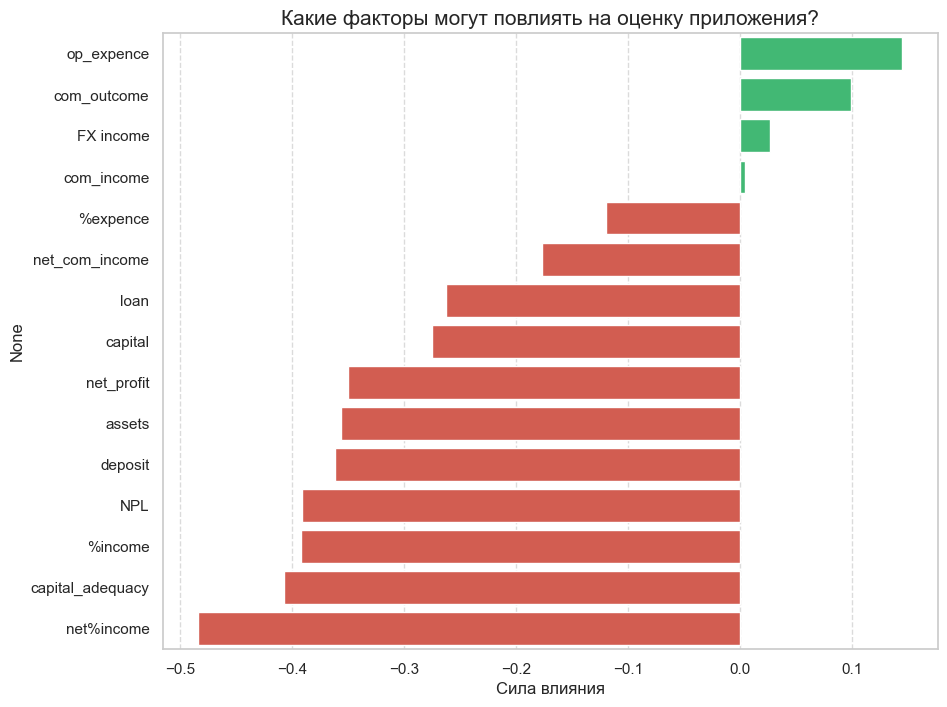

In [255]:
rank_impact = final.drop(['id', 'year'], axis=1).corr(numeric_only=True)[['rank']]
rank_impact = rank_impact.sort_values(by='rank', ascending=False).drop('rank') 

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in rank_impact['rank']] 

sns.barplot(x=rank_impact['rank'], y=rank_impact.index, palette=colors)
plt.title('Какие факторы могут повлиять на оценку приложения?', fontsize=15)
plt.xlabel('Сила влияния')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

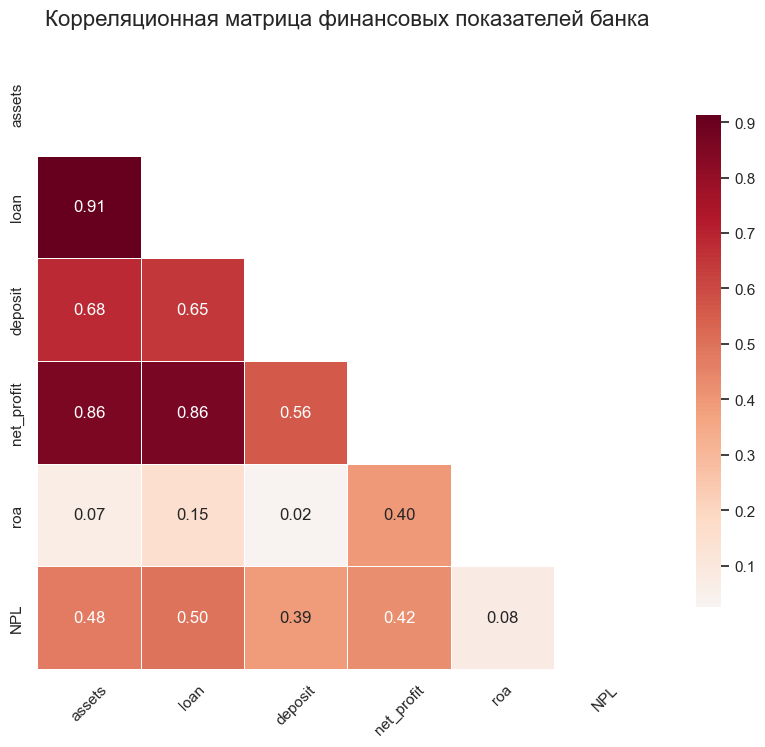

In [256]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Загрузка данных (замените 'data.csv' на ваш файл)
# df = pd.read_csv('your_file.csv')

# Выбираем только нужные колонки для анализа
cols_to_analyze = ['assets', 'loan', 'deposit', 'net_profit', 'roa', 'NPL']

# Убедимся, что данные числовые (удаляем лишние пробелы в названиях, если есть)
for_5.columns = for_5.columns.str.strip()
subset = for_5[cols_to_analyze].apply(pd.to_numeric, errors='coerce')

# 2. Расчет матрицы корреляции
corr_matrix = subset.corr()

# 3. Настройка визуализации
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Создаем маску, чтобы скрыть дублирующуюся верхнюю часть (треугольник)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Отрисовка Heatmap
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,           # Показывать числа внутри ячеек
    fmt=".2f",            # Округление до 2 знаков
    cmap='RdBu_r',        # Цветовая схема (красный - негатив, синий - позитив)
    center=0,             # Центрирование цвета на нуле
    linewidths=0.5,       # Разделительные линии между ячейками
    cbar_kws={"shrink": .8}
)

plt.title('Корреляционная матрица финансовых показателей банка', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.show()

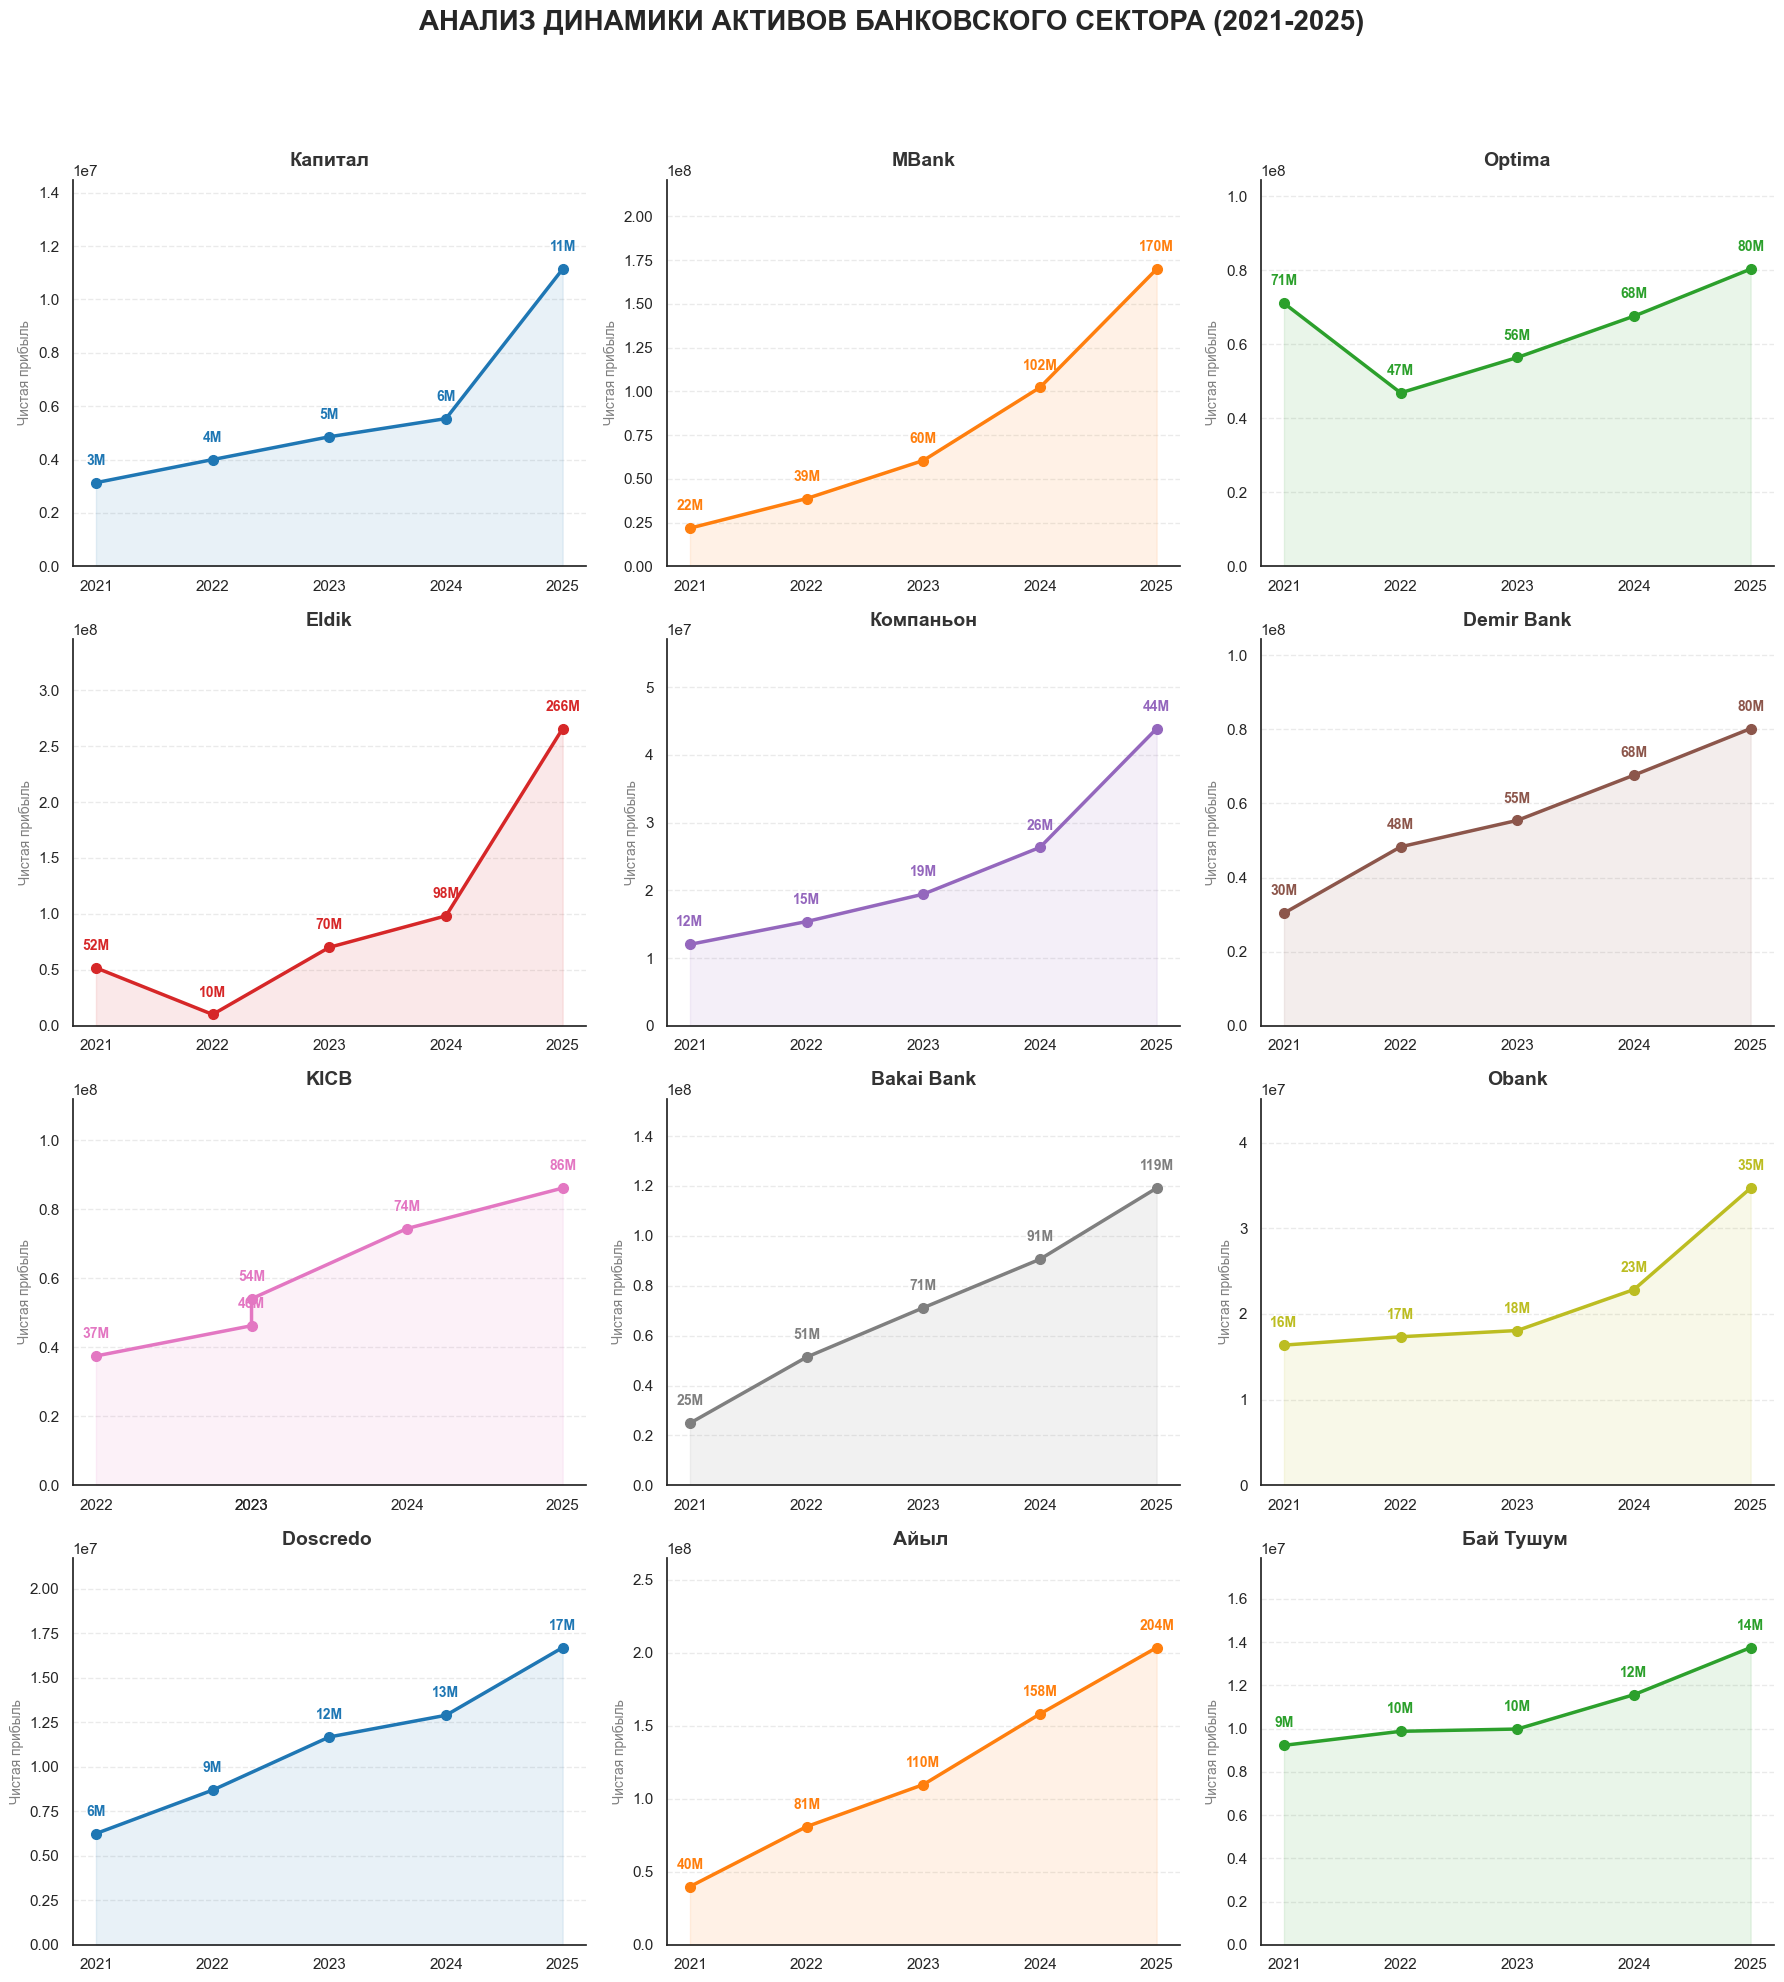

In [257]:
import matplotlib.pyplot as plt
import numpy as np

# Настройка данных
for_5.columns = for_5.columns.str.strip()
banks = for_5['bank'].unique()
n_cols = 3
n_rows = (len(banks) + n_cols - 1) // n_cols

# Создаем холст
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# --- ДОБАВЛЯЕМ ОБЩИЙ ЗАГОЛОВОК ВЕРХУ ---
fig.suptitle('АНАЛИЗ ДИНАМИКИ АКТИВОВ БАНКОВСКОГО СЕКТОРА (2021-2025)', 
             fontsize=20, fontweight='bold', y=1.02) 

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

for i, bank_name in enumerate(banks):
    ax = axes[i]
    color = colors[i % len(colors)]
    
    bank_data = for_5[for_5['bank'] == bank_name].sort_values('year')
    x = bank_data['year'].values
    y = bank_data['assets'].values 

    # Отрисовка области и линии
    ax.fill_between(x, y, color=color, alpha=0.1)
    ax.plot(x, y, color=color, marker='o', linewidth=2.5, markersize=7)
    
    # Подписи данных (Value Labels)
    for xi, yi in zip(x, y):
        label = f'{yi/1e9:.1f}B' if yi >= 1e9 else f'{yi/1e6:.0f}M'
        ax.text(xi, yi + (max(y) * 0.05), label, color=color, 
                ha='center', va='bottom', fontsize=10, fontweight='semibold')

    # Настройка каждой ячейки
    ax.set_title(bank_name, fontsize=14, fontweight='bold', pad=10, color='#333333')
    ax.set_ylabel('Чистая прибыль', fontsize=10, color='gray')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.set_xticks(x)
    ax.set_ylim(bottom=0, top=max(y) * 1.3) # Запас места под подписи сверху
    
    # Убираем лишние рамки (как на современных дашбордах)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Удаление пустых ячеек, если банков меньше, чем мест в сетке
for j in range(len(banks), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Оставляем место под suptitle
plt.show()

C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_7944\3258209970.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg.reset_index(), x='bank', y='roa', palette='viridis')


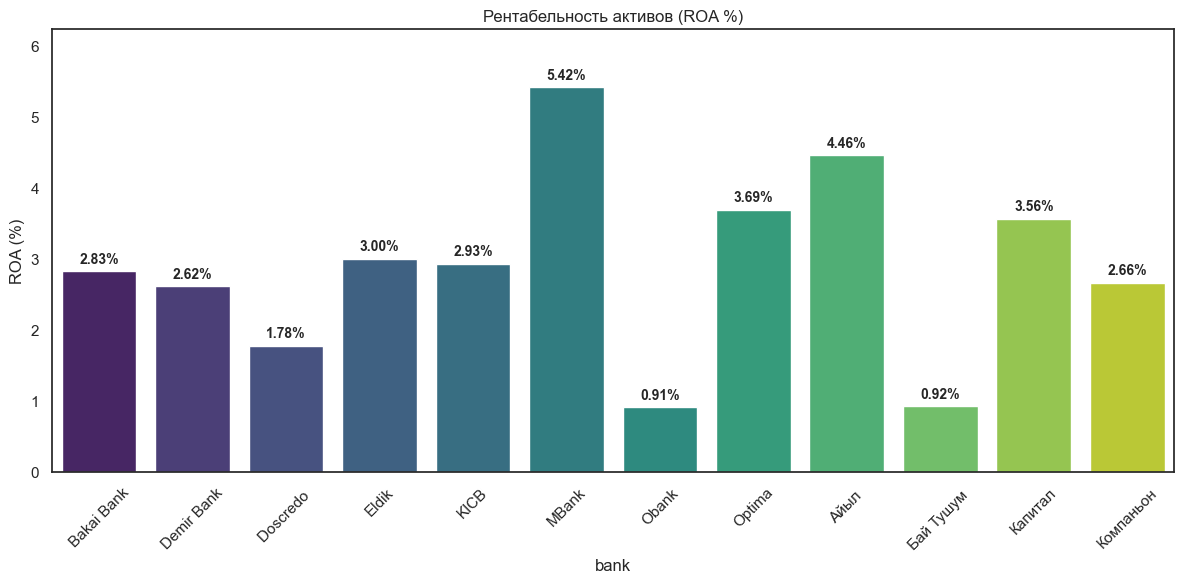

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

# Считаем ROA
avg['roa'] = (avg['net_profit'] / avg['assets']) * 100

plt.figure(figsize=(12,6))

# Рисуем график и сохраняем его в переменную ax для дальнейшей работы
ax = sns.barplot(data=avg.reset_index(), x='bank', y='roa', palette='viridis') 

# --- ДОБАВЛЯЕМ ЗНАЧЕНИЯ В ПРОЦЕНТАХ НАД СТОЛБИКАМИ ---
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.xticks(rotation=45)
plt.title("Рентабельность активов (ROA %)")
plt.ylabel("ROA (%)")

# Немного увеличим лимит по оси Y, чтобы подписи не вылетали за границы
plt.ylim(0, avg['roa'].max() * 1.15) 

plt.tight_layout()
plt.show()

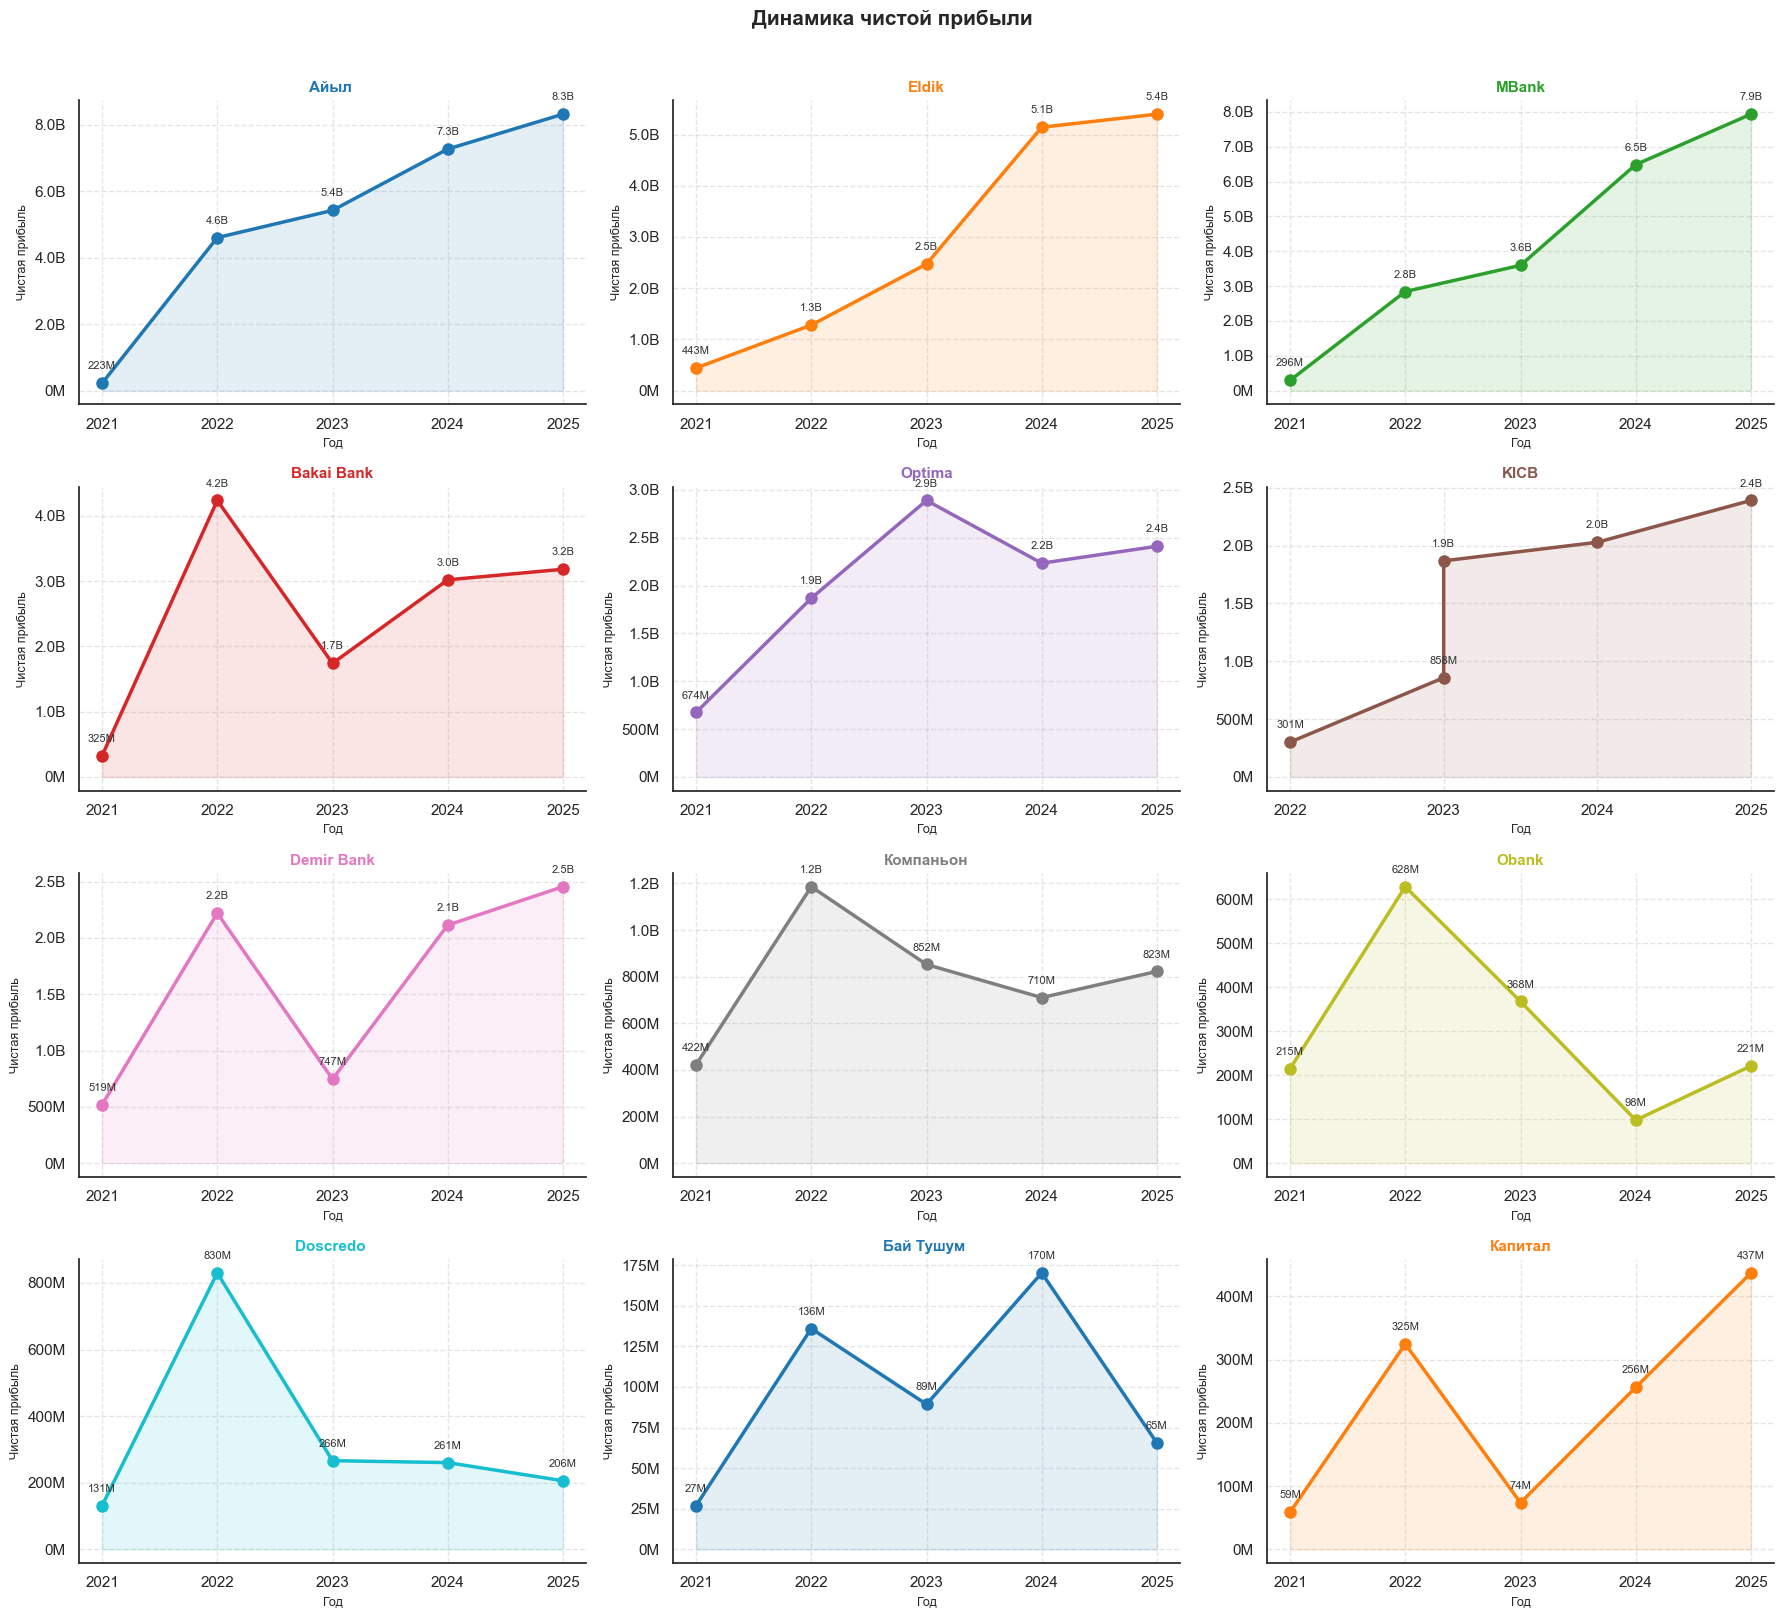

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

#  год \
for_5['year'] = for_5['year'].astype(str).str.extract(r'(\d{4})$').astype(int)

#  Все 12 банков, отсортированных по активам 
all_banks = (
    for_5.groupby('bank')['assets']
    .mean()
    .sort_values(ascending=False)
    .index
)

df_trends = for_5[for_5['bank'].isin(all_banks)].copy()
n = len(all_banks)

palette = sns.color_palette("tab10", n)
bank_colors = dict(zip(all_banks, palette))

def fmt_val(val):
    if abs(val) >= 1_000_000:
        return f'{val/1_000_000:.1f}B'
    return f'{val/1_000:.0f}M'

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, bank in enumerate(all_banks):
    ax = axes[idx]
    sub = df_trends[df_trends['bank'] == bank].sort_values('year')

    ax.plot(
        sub['year'], sub['net_profit'],
        marker='o', linewidth=2.5, markersize=8,
        color=bank_colors[bank]
    )
    ax.fill_between(
        sub['year'], sub['net_profit'],
        alpha=0.12, color=bank_colors[bank]
    )

    for _, row in sub.iterrows():
        ax.annotate(
            fmt_val(row['net_profit']),
            xy=(row['year'], row['net_profit']),
            xytext=(0, 10), textcoords='offset points',
            ha='center', fontsize=8, color='#333333'
        )

    ax.set_title(bank, fontsize=11, fontweight='bold', color=bank_colors[bank])
    ax.set_xticks(sub['year'].unique())
    ax.set_xlabel('Год', fontsize=9)
    ax.set_ylabel('Чистая прибыль', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_val(x)))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

# Скрываем пустые ячейки
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Динамика чистой прибыли",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [260]:
filial.head()

,id,bank,Банк,Филиалы / СК*,Терминалы / Банкоматы,Режим работы (стандарт),График (будни),Суббота,Итого часов в год (прибл.)
0,1,Капитал,Капитал,55,150,,08.0 часов,Выходной,1940
1,2,MBank,MBANK,100,1500,Пн-Пт: 09:00–17:30 / Сб: до 14:00,08.5 часов,5 часов,2330
2,3,Optima,Оптима Банк,50,1200,Пн-Пт: 09:00–17:00 / Сб: дежурные кассы,08.0 часов,Только ТЦ,1960
3,4,Eldik,Элдик Банк (бывш. РСК),120,1100,Пн-Пт: 08:30–16:30,08.0 часов,Выходной,1940
4,5,Компаньон,Компаньон,90,400,Пн-Пт: 08:30–17:30,09.0 часов,Выходной,2200


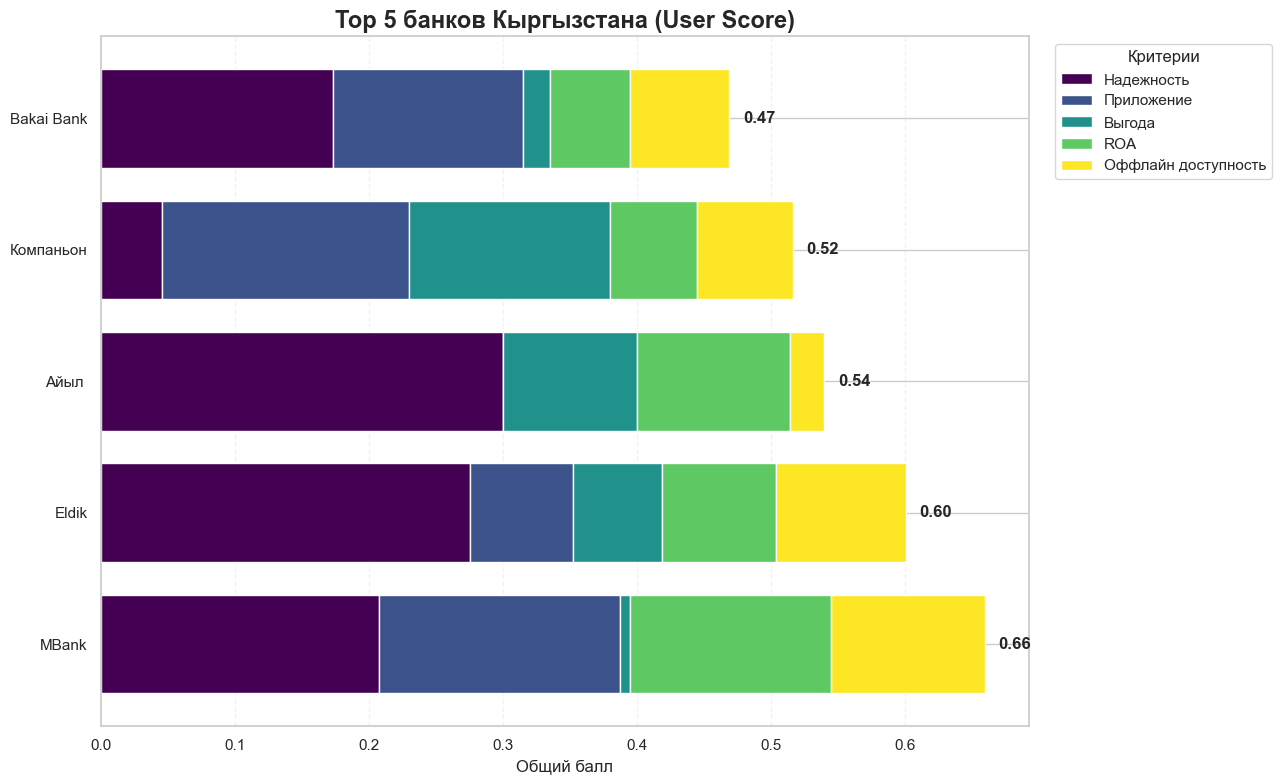

In [263]:
sns.set_theme(style="whitegrid")

# -------------------------------
# 1. Финансовые метрики
# -------------------------------
filial.columns = filial.columns.str.strip()

# убрать дубликаты колонок
filial = filial.loc[:, ~filial.columns.duplicated()]

# если есть bank и Банк -> удалить Банк
if 'bank' in filial.columns and 'Банк' in filial.columns:
    filial = filial.drop(columns='Банк')

# если есть только Банк
elif 'Банк' in filial.columns:
    filial = filial.rename(columns={'Банк':'bank'})

final['expense_ratio'] = (final['%expence'] / final['%income'].replace(0, 1)) * 100
final['commission_share'] = (final['com_income'] / final['%income'].replace(0, 1)) * 100
final['roa'] = (final['net_profit'] / final['assets'].replace(0, 1)) * 100

# -------------------------------
# 2. Средние значения по банкам
# -------------------------------
avg = final.groupby('bank').mean(numeric_only=True).reset_index()

# -------------------------------
# 3. Таблица филиалов
# filial = твоя таблица с колонками:
# ['id','bank','Банк','Филиалы / СК*','Терминалы / Банкоматы',
# 'Режим работы (стандарт)','График (будни)','Суббота',
# 'Итого часов в год (прибл.)']
# -------------------------------

filial.columns = filial.columns.str.strip()

# если название банка в колонке "Банк"

# агрегируем
filial_agg = filial.groupby('bank').agg({
    'Филиалы / СК*':'sum',
    'Терминалы / Банкоматы':'sum',
    'Итого часов в год (прибл.)':'mean'
}).reset_index()

# -------------------------------
# 4. Объединение
# -------------------------------
avg = avg.merge(filial_agg, on='bank', how='left')

# -------------------------------
# 5. Нормализация
# -------------------------------
def scale(col):
    if col.max() == col.min():
        return pd.Series(0.5, index=col.index)
    return (col - col.min()) / (col.max() - col.min())

avg['inv_commissions'] = 1 / (avg['commission_share'] + 0.001)

# Новый скоринг
avg['s_trust']   = scale(avg['assets']) * 0.30
avg['s_app']     = scale(avg['rank']) * 0.20
avg['s_benefit'] = scale(avg['inv_commissions']) * 0.15
avg['s_profit']  = scale(avg['roa']) * 0.15
avg['s_offline'] = (
    scale(avg['Филиалы / СК*']) * 0.60 +
    scale(avg['Терминалы / Банкоматы']) * 0.25 +
    scale(avg['Итого часов в год (прибл.)']) * 0.15
) * 0.15

avg['user_score'] = (
    avg['s_trust'] +
    avg['s_app'] +
    avg['s_benefit'] +
    avg['s_profit'] +
    avg['s_offline']
)

# -------------------------------
# 6. Top 5
# -------------------------------
top5_user = avg.sort_values('user_score', ascending=False).head(5)

# -------------------------------
# 7. Красивый stacked graph
# -------------------------------
plot_df = top5_user.set_index('bank')[[
    's_trust','s_app','s_benefit',
    's_profit','s_offline'
]]

plot_df.columns = [
    'Надежность',
    'Приложение',
    'Выгода',
    'ROA',
    'Оффлайн доступность'
]

ax = plot_df.plot(
    kind='barh',
    stacked=True,
    figsize=(13,8),
    colormap='viridis',
    edgecolor='white',
    width=0.75
)

plt.title('Top 5 банков Кыргызстана (User Score)', fontsize=17, weight='bold')
plt.xlabel('Общий балл')
plt.ylabel('')

# подписи справа
for i, val in enumerate(top5_user['user_score']):
    plt.text(val + 0.01, i, f'{val:.2f}', va='center', fontweight='bold')

plt.legend(title='Критерии', bbox_to_anchor=(1.02,1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()
